# Phase 6: Customer Segmentation (RFM Analysis)

### Objective

Segment customers using **Recency**, **Frequency**, and **Monetary (RFM)** analysis to identify customer behavior patterns and support targeted business strategies.

### Dataset

- `customer_features.csv`

### Workflow

1. Load Customer Features
2. Create RFM Dataset
3. Calculate RFM Scores
4. Create Customer Segments
5. Analyze Segment Distribution
6. Visualize Customer Segments
7. Business Insights

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook

%matplotlib inline

In [2]:
# Load customer features dataset

customer_features = pd.read_csv(
    "../data/processed/customer_features.csv"
)

customer_features.head()

,customer_unique_id,total_orders,total_spent,average_order_value,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,336


In [3]:
# Display dataset shape

customer_features.shape

(96096, 5)

In [4]:
customer_features.columns

Index(['customer_unique_id', 'total_orders', 'total_spent',
       'average_order_value', 'recency_days'],
      dtype='str')

### Create RFM Dataset

In [5]:
# Select required columns for RFM analysis

rfm = customer_features[
    [
        "customer_unique_id",
        "recency_days",
        "total_orders",
        "total_spent"
    ]
].copy()

# Rename columns for better readability

rfm.rename(
    columns={
        "recency_days": "Recency",
        "total_orders": "Frequency",
        "total_spent": "Monetary"
    },
    inplace=True
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [6]:
### Calculate RFM Scores

# Assign Recency score (Lower Recency = Higher Score)

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

# Assign Frequency score (Higher Frequency = Higher Score)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Assign Monetary score (Higher Spending = Higher Score)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4


### Create RFM Score


In [7]:
# Convert scores to string

rfm["R_Score"] = rfm["R_Score"].astype(str)
rfm["F_Score"] = rfm["F_Score"].astype(str)
rfm["M_Score"] = rfm["M_Score"].astype(str)

# Combine R, F and M scores

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214


In [8]:
# Create customer segments based on RFM scores

def segment_customer(row):

    if row["R_Score"] == "5" and row["F_Score"] == "5":
        return "Champions"

    elif row["R_Score"] >= "4" and row["F_Score"] >= "4":
        return "Loyal Customers"

    elif row["R_Score"] >= "4":
        return "Potential Loyalists"

    elif row["R_Score"] == "3":
        return "Need Attention"

    elif row["R_Score"] <= "2" and row["F_Score"] >= "3":
        return "At Risk"

    else:
        return "Lost Customers"


# Apply segmentation

rfm["Customer_Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers


In [9]:
# Count customers in each segment

segment_counts = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

# Rename columns

segment_counts.columns = [
    "Customer_Segment",
    "Customer_Count"
]

# Display segment counts

segment_counts

,Customer_Segment,Customer_Count
0,Potential Loyalists,23170
1,At Risk,22967
2,Need Attention,19043
3,Lost Customers,15463
4,Loyal Customers,11500
5,Champions,3953


In [10]:
# Calculate percentage of customers in each segment

segment_counts["Percentage"] = (
    segment_counts["Customer_Count"]
    / len(rfm)
    * 100
).round(2)

# Display results

segment_counts

,Customer_Segment,Customer_Count,Percentage
0,Potential Loyalists,23170,24.11
1,At Risk,22967,23.90
2,Need Attention,19043,19.82
3,Lost Customers,15463,16.09
4,Loyal Customers,11500,11.97
5,Champions,3953,4.11


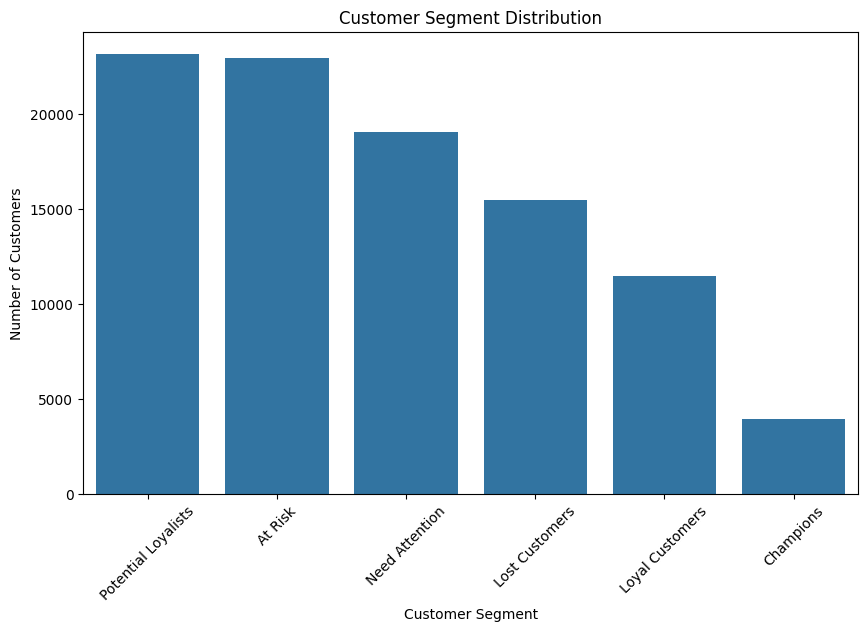

In [11]:
# Create bar chart for customer segments

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_counts,
    x="Customer_Segment",
    y="Customer_Count"
)

# Add chart title and labels

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Rotate labels

plt.xticks(rotation=45)

# Display chart

plt.show()

In [12]:
# Calculate total revenue for each customer segment

segment_revenue = (
    rfm.groupby("Customer_Segment")["Monetary"]
    .sum()
    .reset_index()
)

# Sort by revenue

segment_revenue = segment_revenue.sort_values(
    by="Monetary",
    ascending=False
)

# Display results

segment_revenue

,Customer_Segment,Monetary
0,At Risk,3823132.71
5,Potential Loyalists,3807919.63
4,Need Attention,2965015.09
2,Lost Customers,2499350.15
3,Loyal Customers,1978405.44
1,Champions,769730.22


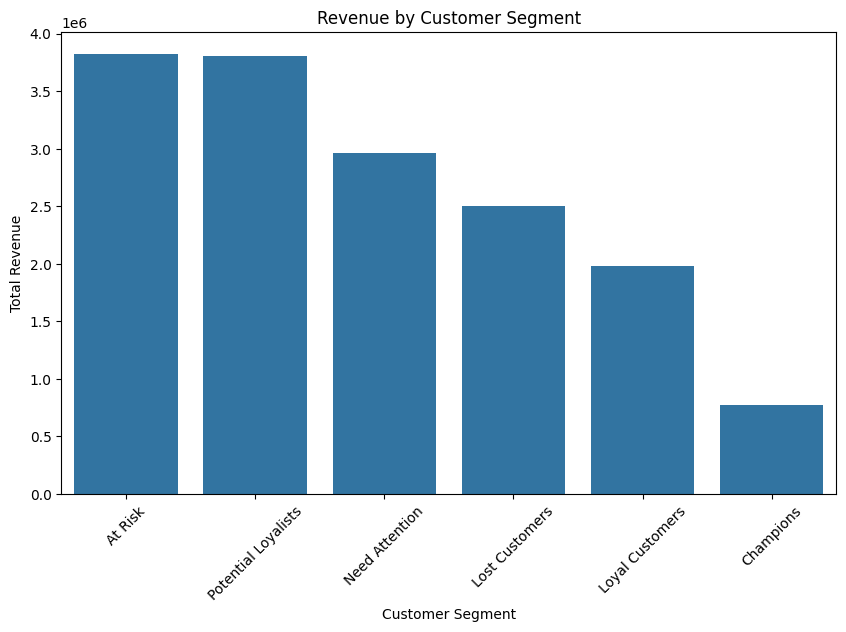

In [13]:
# Create bar chart for revenue by customer segment

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_revenue,
    x="Customer_Segment",
    y="Monetary"
)

# Add chart title and labels

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

# Rotate labels

plt.xticks(rotation=45)

# Display chart

plt.show()

In [14]:
# Save RFM dataset

rfm.to_csv(
    "../data/processed/rfm_customer_segments.csv",
    index=False
)

print("RFM customer segmentation dataset saved successfully.")

RFM customer segmentation dataset saved successfully.
